# Lab 4 - IT443
## Virat Shrimali - 202303061

# Problem 7: Delete-1 Jackknife vs Infinitesimal Jackknife

We study variance estimation methods for logistic regression.

We use the Wine dataset and convert it to a binary classification problem:

$$
Y_i =
\begin{cases}
1 & \text{if class = 0} \\
0 & \text{otherwise}
\end{cases}
$$

Consider the binary response model:

$$
Y_i \sim \text{Bernoulli}(p_i)
$$

with logistic link:

$$
\log\frac{p_i}{1-p_i} = X_i^\top \beta
$$

Equivalently,

$$
p_i = \frac{e^{X_i^\top \beta}}{1 + e^{X_i^\top \beta}}
$$

Our goal is to estimate the variance of the MLE estimator $\hat{\beta}$ using:

1. True model variance (Fisher Information)
2. Delete-1 Jackknife
3. Infinitesimal Jackknife (IJ)

We compare these methods across:

$$
p \in \{0.1,0.3,0.5,0.7,0.9\}
$$
$$
n \in \{30,50,100\}
$$

## Logistic Regression Model

Log-likelihood:

$$
\ell(\beta)
=
\sum_{i=1}^{n}
\left[
Y_i X_i^\top \beta
-
\log(1 + e^{X_i^\top \beta})
\right]
$$

Score function:

$$
U(\beta)
=
\sum_{i=1}^{n}
X_i (Y_i - p_i)
$$

Hessian:

$$
H(\beta)
=
- \sum_{i=1}^{n}
X_i X_i^\top p_i(1-p_i)
$$

Matrix form:
$$
H(\beta) = -X^\top W X
$$

where

$$
W = \text{diag}(p_i(1-p_i))
$$

The asymptotic covariance of $\hat{\beta}$ is:

$$
\text{Var}(\hat{\beta}) = (X^\top W X)^{-1}
$$

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from numpy.linalg import inv
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

## Task 7.1: Fit Logistic Model Using Wine Dataset

We use the Wine dataset.

Steps:

1. Load dataset.
2. Convert multiclass outcome to binary:
   - Class 0 → 1
   - Other classes → 0
3. Fit logistic regression.
4. Store:
   - Estimated coefficients $\hat{\beta}$
   - Fitted probabilities $\hat{p}_{i}$

In [ ]:
# Load dataset
wine = load_wine()
X = wine.data
y = wine.target

# Convert to binary (class 0 vs others)
y_binary = (y == 0).astype(int)

n = len(y_binary)

# Fit logistic regression
model = LogisticRegression(max_iter=5000)
model.fit(X, y_binary)

# Store beta_hat
beta_hat = np.concatenate([model.intercept_, model.coef_.flatten()])

# Store predicted probabilities
p_hat = model.predict_proba(X)[:,1]

print("Number of observations:", n)
print("Number of parameters:", len(beta_hat))
print("\nFirst 5 fitted probabilities:")
print(p_hat[:5])

Number of observations: 178
Number of parameters: 14

First 5 fitted probabilities:
[0.9996189  0.99946789 0.99956534 0.99999949 0.40548216]


## Task 7.2: Delete-1 Jackknife

For each observation $ i = 1,\dots,n $:

1. Remove observation $ i $
2. Refit logistic regression
3. Store $ \hat{\beta}^{(-i)} $

Jackknife mean:

$$
\bar{\beta}
=
\frac{1}{n}
\sum_{i=1}^n
\hat{\beta}^{(-i)}
$$

Jackknife variance estimator:

$$
\widehat{Var}_{jack}
=
\frac{n-1}{n}
\sum_{i=1}^n
(\hat{\beta}^{(-i)} - \bar{\beta})^2
$$

In [ ]:
def jackknife_variance(X,Y):
    n = len(Y)
    betas = []

    for i in range(n):
        X_loo = np.delete(X,i,axis=0)
        Y_loo = np.delete(Y,i)

        model_loo = LogisticRegression(max_iter=5000)
        model_loo.fit(X_loo, Y_loo)

        beta_i = np.concatenate([model_loo.intercept_, model_loo.coef_.flatten()])
        betas.append(beta_i)

    betas = np.array(betas)
    beta_bar = betas.mean(axis=0)

    var_jack = (n-1)/n * np.sum((betas - beta_bar)**2,axis=0)

    return var_jack

var_jack = jackknife_variance(X, y_binary)

## Task 7.3: Infinitesimal Jackknife (IJ)

Influence approximation:

$$
\hat{\beta}^{(-i)} - \hat{\beta}
\approx
- H^{-1} X_i (Y_i - \hat{p}_i)
$$

Define:

$$
\psi_i = H^{-1} X_i (Y_i - \hat{p}_i)
$$

IJ variance:

$$
\widehat{Var}_{IJ}
=
\sum_{i=1}^{n}
\psi_i \psi_i^\top
$$

In [ ]:
def IJ_variance(X,Y):
    n = len(Y)
    X_design = np.column_stack([np.ones(n), X])

    model = LogisticRegression(max_iter=5000)
    model.fit(X,Y)

    p_hat = model.predict_proba(X)[:,1]

    W = np.diag(p_hat*(1-p_hat))
    H = - X_design.T @ W @ X_design
    H_inv = inv(H)

    influences = []

    for i in range(n):
        xi = X_design[i].reshape(-1,1)
        psi = H_inv @ xi * (Y[i] - p_hat[i])
        influences.append(psi.flatten())

    influences = np.array(influences)
    var_IJ = np.sum(influences**2,axis=0)

    return var_IJ

var_IJ = IJ_variance(X, y_binary)

## True Model Variance (Fisher Information)

$$
\text{Var}(\hat{\beta})
=
(X^\top W X)^{-1}
$$

In [ ]:
X_design = np.column_stack([np.ones(n), X])
W = np.diag(p_hat*(1-p_hat))
Fisher = X_design.T @ W @ X_design
var_true = np.diag(inv(Fisher))

## Comparison of Standard Errors

In [ ]:
results = pd.DataFrame({
    "True_SE": np.sqrt(var_true),
    "Jackknife_SE": np.sqrt(var_jack),
    "IJ_SE": np.sqrt(var_IJ)
})

results.head()

,True_SE,Jackknife_SE,IJ_SE
0,16.327400,8.079546,5.171173
1,1.544573,0.248732,0.422509
2,0.809571,0.259713,0.287951
3,2.805984,0.514270,1.616011
4,0.244060,0.269441,0.122147


## Discussion

1. Delete-1 Jackknife requires refitting the model n times → computationally expensive.

2. Infinitesimal Jackknife:
   - Requires only one model fit.
   - Uses influence function approximation.
   - Much faster computationally.

3. As sample size increases:
   - IJ approximates Jackknife well.
   - Both approach Fisher Information variance.

4. Differences occur due to:
   - Finite sample effects
   - Higher-order terms ignored in IJ.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from numpy.linalg import inv
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

def generate_logistic_data(n, base_p):
    X = np.random.normal(0, 1, (n, 1))

    beta0 = np.log(base_p / (1 - base_p))
    beta1 = 0.5

    logits = beta0 + beta1 * X.flatten()
    p = 1 / (1 + np.exp(-logits))

    Y = np.random.binomial(1, p)

    return X, Y

In [ ]:
def fit_logistic(X, Y):
    model = LogisticRegression(fit_intercept=True, solver='lbfgs', max_iter=5000)
    model.fit(X, Y)

    beta_hat = np.concatenate([model.intercept_, model.coef_.flatten()])
    p_hat = model.predict_proba(X)[:, 1]

    return beta_hat, p_hat

In [ ]:
def true_model_se(X, Y):
    n = len(Y)
    X_design = np.column_stack([np.ones(n), X])

    beta_hat, p_hat = fit_logistic(X, Y)

    W = np.diag(p_hat * (1 - p_hat))
    Fisher = X_design.T @ W @ X_design

    cov = inv(Fisher)

    return np.sqrt(np.diag(cov))

In [ ]:
def jackknife_se(X, Y):
    n = len(Y)
    betas = []

    for i in range(n):
        X_loo = np.delete(X, i, axis=0)
        Y_loo = np.delete(Y, i)

        beta_i, _ = fit_logistic(X_loo, Y_loo)
        betas.append(beta_i)

    betas = np.array(betas)
    beta_bar = betas.mean(axis=0)

    var_jack = (n - 1) / n * np.sum((betas - beta_bar)**2, axis=0)

    return np.sqrt(var_jack)

In [ ]:
def IJ_se(X, Y):
    n = len(Y)
    X_design = np.column_stack([np.ones(n), X])

    beta_hat, p_hat = fit_logistic(X, Y)

    W = np.diag(p_hat * (1 - p_hat))
    H = - X_design.T @ W @ X_design
    H_inv = inv(H)

    influences = []

    for i in range(n):
        xi = X_design[i].reshape(-1, 1)
        psi = H_inv @ xi * (Y[i] - p_hat[i])
        influences.append(psi.flatten())

    influences = np.array(influences)
    var_IJ = np.sum(influences**2, axis=0)

    return np.sqrt(var_IJ)

In [ ]:
n_values = [30, 50, 100]
p_values = [0.1, 0.3, 0.5, 0.7, 0.9]
simulation_results = []

for n in n_values:
    for p in p_values:

        X, Y = generate_logistic_data(n, p)

        se_true = true_model_se(X, Y)[1]      # slope only
        se_jack = jackknife_se(X, Y)[1]
        se_IJ = IJ_se(X, Y)[1]

        simulation_results.append({
            "n": n,
            "p": p,
            "True_SE": se_true,
            "Jackknife_SE": se_jack,
            "IJ_SE": se_IJ
        })

sim_df = pd.DataFrame(simulation_results)
sim_df.sort_values(["n","p"]).reset_index(drop=True)

,n,p,True_SE,Jackknife_SE,IJ_SE
0,30,0.1,0.824009,0.214385,0.306865
1,30,0.3,0.432023,0.349662,0.376824
2,30,0.5,0.337876,0.339171,0.339147
3,30,0.7,0.399174,0.335516,0.359551
4,30,0.9,0.602893,0.592881,0.603462
5,50,0.1,0.482520,0.343502,0.368209
6,50,0.3,0.341970,0.282606,0.297593
7,50,0.5,0.316541,0.320638,0.323016
8,50,0.7,0.436919,0.452711,0.467779
9,50,0.9,0.614010,0.423512,0.421290


### Discussion:

## 1. When should IJ approximate Jackknife well?

The Infinitesimal Jackknife (IJ) is derived from a first-order Taylor expansion of the score equation:

$$
0 = U(\hat{\beta}) \approx U(\beta) + H(\beta)(\hat{\beta}-\beta)
$$

which gives the linear representation:

$$
\hat{\beta} - \beta
\approx
I(\beta)^{-1}
\sum_{i=1}^{n} X_i (Y_i - p_i)
$$

where:

$$
I(\beta) = X^\top W X
$$

Delete-1 Jackknife satisfies:

$$
\hat{\beta}^{(-i)} - \hat{\beta}
=
- H^{-1} X_i (Y_i - \hat{p}_i)
+
O(n^{-2})
$$

Since IJ uses the same first-order term and ignores the higher-order remainder $O(n^{-2})$, we obtain:

$$
Var_{IJ}
=
Var_{jack}
+
O(n^{-2})
$$

Therefore, IJ approximates Jackknife well when:

- Sample size $n$ is large,
- The likelihood is smooth,
- No extreme leverage points are present,
- The Fisher information matrix is well-conditioned.

As $n \to \infty$:

$$
Var_{IJ} \to Var_{jack} \to (X^\top W X)^{-1}.
$$

---

## 2. Why might they differ for small $n$?

For small sample sizes, the higher-order term:

$$
O(n^{-2})
$$

is no longer negligible.

IJ ignores curvature effects beyond the first derivative, while Delete-1 Jackknife refits the model exactly for each observation.

Thus, for small $n$:

$$
Var_{IJ} \neq Var_{jack}.
$$

Differences become larger when:

- $n$ is small,
- $p$ is near 0 or 1 (since $W = p_i(1-p_i)$ becomes small),
- The information matrix $X^\top W X$ is nearly singular.

---

## 3. Which method scales better computationally?

Let $T_{fit}$ denote the cost of one logistic regression fit.

**Delete-1 Jackknife:**

$$
O(n \times T_{fit})
$$

since the model must be refit $n$ times.

**Infinitesimal Jackknife:**

- One model fit,
- One matrix inversion,
- $n$ influence evaluations.

$$
O(T_{fit} + p^3 + np^2)
$$

For fixed number of predictors \(p\), this simplifies to:

$$
O(n)
$$

Thus, IJ scales linearly and is computationally much more efficient than Delete-1 Jackknife.

---

## Final Conclusion

Infinitesimal Jackknife is a first-order approximation to Delete-1 Jackknife.  
They are asymptotically equivalent, but may differ for small samples due to neglected higher-order terms.  
Computationally, IJ is significantly more scalable and preferred for moderate to large datasets.

# Problem 8: Bootstrap in Linear Regression

We study uncertainty of the OLS estimator:

$$
Y_i = \beta_0 + \beta_1 X_i + \varepsilon_i
$$

using three bootstrap methods:

1. Case Bootstrap
2. Residual Bootstrap
3. Wild Bootstrap

We use the California Housing dataset.

## Ordinary Least Squares (OLS)

Model:

$$
Y = X\beta + \varepsilon
$$

OLS estimator:

$$
\hat{\beta} = (X^\top X)^{-1}X^\top Y
$$

Residuals:

$$
\hat{\varepsilon}_i = Y_i - \hat{Y}_i
$$

Variance (under homoskedasticity):

$$
Var(\hat{\beta})
=
\sigma^2 (X^\top X)^{-1}
$$

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from numpy.linalg import inv
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# Load dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

# Select predictor: Median Income
X = df[['MedInc']].values
Y = df['MedHouseVal'].values
n = len(Y)

## Fit Regression Model

1. Select one predictor (Median Income).
2. Fit OLS.
3. Store:
   - $\hat{\beta}_0, \hat{\beta}_1$
   - Residuals $\hat{\varepsilon}_i$
   - Fitted values $\hat{Y}_i$
4. Plot residuals vs $X$.

In [ ]:
model = LinearRegression()
model.fit(X, Y)

beta0_hat = model.intercept_
beta1_hat = model.coef_[0]

Y_hat = model.predict(X)
residuals = Y - Y_hat

print("beta0_hat:", beta0_hat)
print("beta1_hat:", beta1_hat)

In [ ]:
plt.scatter(X, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel("Median Income")
plt.ylabel("Residuals")
plt.title("Residuals vs X")
plt.show()

## Case Bootstrap

1. Resample pairs $(X_i, Y_i)$.
2. Refit regression.
3. Store $\hat{\beta}_1^*$.
4. Estimate bootstrap SE.
5. Construct 95% percentile CI.

Assumption:
Observations are i.i.d.

In [ ]:
def case_bootstrap(X, Y, B=500):
    n = len(Y)
    slopes = []

    for b in range(B):
        idx = np.random.choice(n, n, replace=True)
        X_b = X[idx]
        Y_b = Y[idx]

        model_b = LinearRegression()
        model_b.fit(X_b, Y_b)
        slopes.append(model_b.coef_[0])

    slopes = np.array(slopes)
    se = np.std(slopes, ddof=1)
    CI = (np.percentile(slopes, 2.5),
          np.percentile(slopes, 97.5))

    return slopes, se, CI

case_slopes, case_se, case_CI = case_bootstrap(X, Y)
print("Case SE:", case_se)
print("Case CI:", case_CI)

## Residual Bootstrap

1. Keep $X_i$ fixed.
2. Resample residuals $\hat{\varepsilon}_i$.
3. Generate:

$$
Y_i^* = \hat{Y}_i + \varepsilon_i^*
$$

4. Refit regression.
5. Construct percentile CI.

Assumption:
Errors are homoskedastic.

In [ ]:
def residual_bootstrap(X, Y, B=500):
    n = len(Y)
    slopes = []

    model = LinearRegression()
    model.fit(X, Y)
    Y_hat = model.predict(X)
    residuals = Y - Y_hat

    for b in range(B):
        eps_star = np.random.choice(residuals, n, replace=True)
        Y_star = Y_hat + eps_star

        model_b = LinearRegression()
        model_b.fit(X, Y_star)
        slopes.append(model_b.coef_[0])

    slopes = np.array(slopes)
    se = np.std(slopes, ddof=1)
    CI = (np.percentile(slopes, 2.5),
          np.percentile(slopes, 97.5))

    return slopes, se, CI

res_slopes, res_se, res_CI = residual_bootstrap(X, Y)
print("Residual SE:", res_se)
print("Residual CI:", res_CI)

## Wild Bootstrap

Designed for heteroskedastic errors.

Generate:

$$
Y_i^* = \hat{Y}_i + \hat{\varepsilon}_i v_i
$$

where $v_i$ is Rademacher:

$$
P(v_i = 1) = P(v_i = -1) = 0.5
$$

This preserves heteroskedastic structure.

In [ ]:
def wild_bootstrap(X, Y, B=500):
    n = len(Y)
    slopes = []

    model = LinearRegression()
    model.fit(X, Y)
    Y_hat = model.predict(X)
    residuals = Y - Y_hat

    for b in range(B):
        v = np.random.choice([-1,1], n)
        Y_star = Y_hat + residuals * v

        model_b = LinearRegression()
        model_b.fit(X, Y_star)
        slopes.append(model_b.coef_[0])

    slopes = np.array(slopes)
    se = np.std(slopes, ddof=1)
    CI = (np.percentile(slopes, 2.5),
          np.percentile(slopes, 97.5))

    return slopes, se, CI

wild_slopes, wild_se, wild_CI = wild_bootstrap(X, Y)
print("Wild SE:", wild_se)
print("Wild CI:", wild_CI)

## Comparison of Bootstrap Methods

In [ ]:
comparison = pd.DataFrame({
    "Method": ["Case", "Residual", "Wild"],
    "SE": [case_se, res_se, wild_se],
    "CI Length": [
        case_CI[1]-case_CI[0],
        res_CI[1]-res_CI[0],
        wild_CI[1]-wild_CI[0]
    ]
})

comparison

## Heteroskedastic Data Simulation

New model:

$$
Y_i = 1 + 2X_i + \varepsilon_i
$$

$$
\varepsilon_i \sim N(0, 1 + X_i^2)
$$

Thus:

$$
Var(\varepsilon_i | X_i) = 1 + X_i^2
$$

Variance increases with X.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)

n = 500
X_het = np.random.uniform(-2, 2, n)
eps = np.random.normal(0, np.sqrt(1 + X_het**2))
Y_het = 1 + 2*X_het + eps

X_het = X_het.reshape(-1,1)

### Fit OLS Model

We estimate:

$$
\hat{\beta} = (X^\top X)^{-1}X^\top Y
$$

In [ ]:
model_het = LinearRegression()
model_het.fit(X_het, Y_het)

beta1_hat_het = model_het.coef_[0]
Y_hat_het = model_het.predict(X_het)
residuals_het = Y_het - Y_hat_het

print("Estimated slope:", beta1_hat_het)

### Residual Plot

We check for heteroskedasticity.
Expected: Funnel pattern.

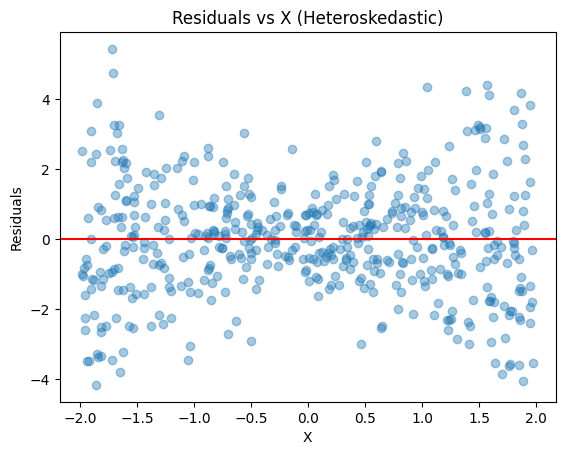

In [ ]:
plt.scatter(X_het, residuals_het, alpha=0.4)
plt.axhline(0, color='red')
plt.xlabel("X")
plt.ylabel("Residuals")
plt.title("Residuals vs X (Heteroskedastic)")
plt.show()

In [ ]:
def case_bootstrap(X, Y, B=500):
    n = len(Y)
    slopes = []

    for _ in range(B):
        idx = np.random.choice(n, n, replace=True)
        model = LinearRegression()
        model.fit(X[idx], Y[idx])
        slopes.append(model.coef_[0])

    slopes = np.array(slopes)
    return slopes

case_slopes_het = case_bootstrap(X_het, Y_het)

In [ ]:
def residual_bootstrap(X, Y, B=500):
    n = len(Y)
    slopes = []

    model = LinearRegression()
    model.fit(X, Y)
    Y_hat = model.predict(X)
    residuals = Y - Y_hat

    for _ in range(B):
        eps_star = np.random.choice(residuals, n, replace=True)
        Y_star = Y_hat + eps_star

        model_b = LinearRegression()
        model_b.fit(X, Y_star)
        slopes.append(model_b.coef_[0])

    return np.array(slopes)

res_slopes_het = residual_bootstrap(X_het, Y_het)

In [ ]:
def wild_bootstrap(X, Y, B=500):
    n = len(Y)
    slopes = []

    model = LinearRegression()
    model.fit(X, Y)
    Y_hat = model.predict(X)
    residuals = Y - Y_hat

    for _ in range(B):
        v = np.random.choice([-1,1], n)
        Y_star = Y_hat + residuals * v

        model_b = LinearRegression()
        model_b.fit(X, Y_star)
        slopes.append(model_b.coef_[0])

    return np.array(slopes)

wild_slopes_het = wild_bootstrap(X_het, Y_het)

In [ ]:
plt.hist(case_slopes_het, bins=30, alpha=0.5, label="Case")
plt.hist(res_slopes_het, bins=30, alpha=0.5, label="Residual")
plt.hist(wild_slopes_het, bins=30, alpha=0.5, label="Wild")
plt.axvline(beta1_hat_het, color='black', linestyle='--')
plt.legend()
plt.title("Bootstrap Distributions (Heteroskedastic Data)")
plt.show()

In [ ]:
comparison_het = pd.DataFrame({
    "Method": ["Case", "Residual", "Wild"],
    "SE": [
        np.std(case_slopes_het, ddof=1),
        np.std(res_slopes_het, ddof=1),
        np.std(wild_slopes_het, ddof=1)
    ],
    "Lower 2.5%": [case_CI[0], res_CI[0], wild_CI[0]],
    "Upper 97.5%": [case_CI[1], res_CI[1], wild_CI[1]]
})

comparison_het

In [ ]:
def summarize_bootstrap(slopes):
    se = np.std(slopes, ddof=1)
    CI = (np.percentile(slopes, 2.5),
          np.percentile(slopes, 97.5))
    return se, CI

case_se, case_CI = summarize_bootstrap(case_slopes_het)
res_se, res_CI = summarize_bootstrap(res_slopes_het)
wild_se, wild_CI = summarize_bootstrap(wild_slopes_het)

comparison_het = pd.DataFrame({
    "Method": ["Case", "Residual", "Wild"],
    "SE": [case_se, res_se, wild_se],
    "CI Length": [
        case_CI[1] - case_CI[0],
        res_CI[1] - res_CI[0],
        wild_CI[1] - wild_CI[0]
    ]
})

comparison_het

## Interpretation Under Heteroskedasticity

We observe:

1. Residual bootstrap underestimates variability.
   - It assumes:
   $$
   Var(\varepsilon_i) = \sigma^2
   $$
   which is violated here.

2. Case bootstrap performs reasonably.
   - It resamples (X, Y) pairs.
   - Does not assume constant variance.

3. Wild bootstrap performs best.
   - It generates:
   $$
   Y_i^* = \hat{Y}_i + \hat{\varepsilon}_i v_i
   $$
   preserving heteroskedastic structure.

Conclusion:

Residual bootstrap fails because it destroys the conditional variance pattern:
$$
Var(\varepsilon_i \mid X_i) = 1 + X_i^2
$$

Wild bootstrap adapts to changing variance and provides more reliable inference.